In [63]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from mpl_toolkits import mplot3d
from sklearn.tree import plot_tree
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold

from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.naive_bayes import MultinomialNB,BernoulliNB,GaussianNB
from sklearn.linear_model import LogisticRegression,PassiveAggressiveClassifier
from sklearn.svm import SVC,SVR
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier,AdaBoostClassifier,ExtraTreesClassifier,GradientBoostingClassifier,BaggingClassifier
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor,RadiusNeighborsClassifier
from sklearn.decomposition import PCA,TruncatedSVD

In [64]:
df = pd.read_csv('Iris.csv')
print(df.head())
print(df.columns)
df.shape

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


(150, 6)

/tmp/ipykernel_2546/1590062410.py:2: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



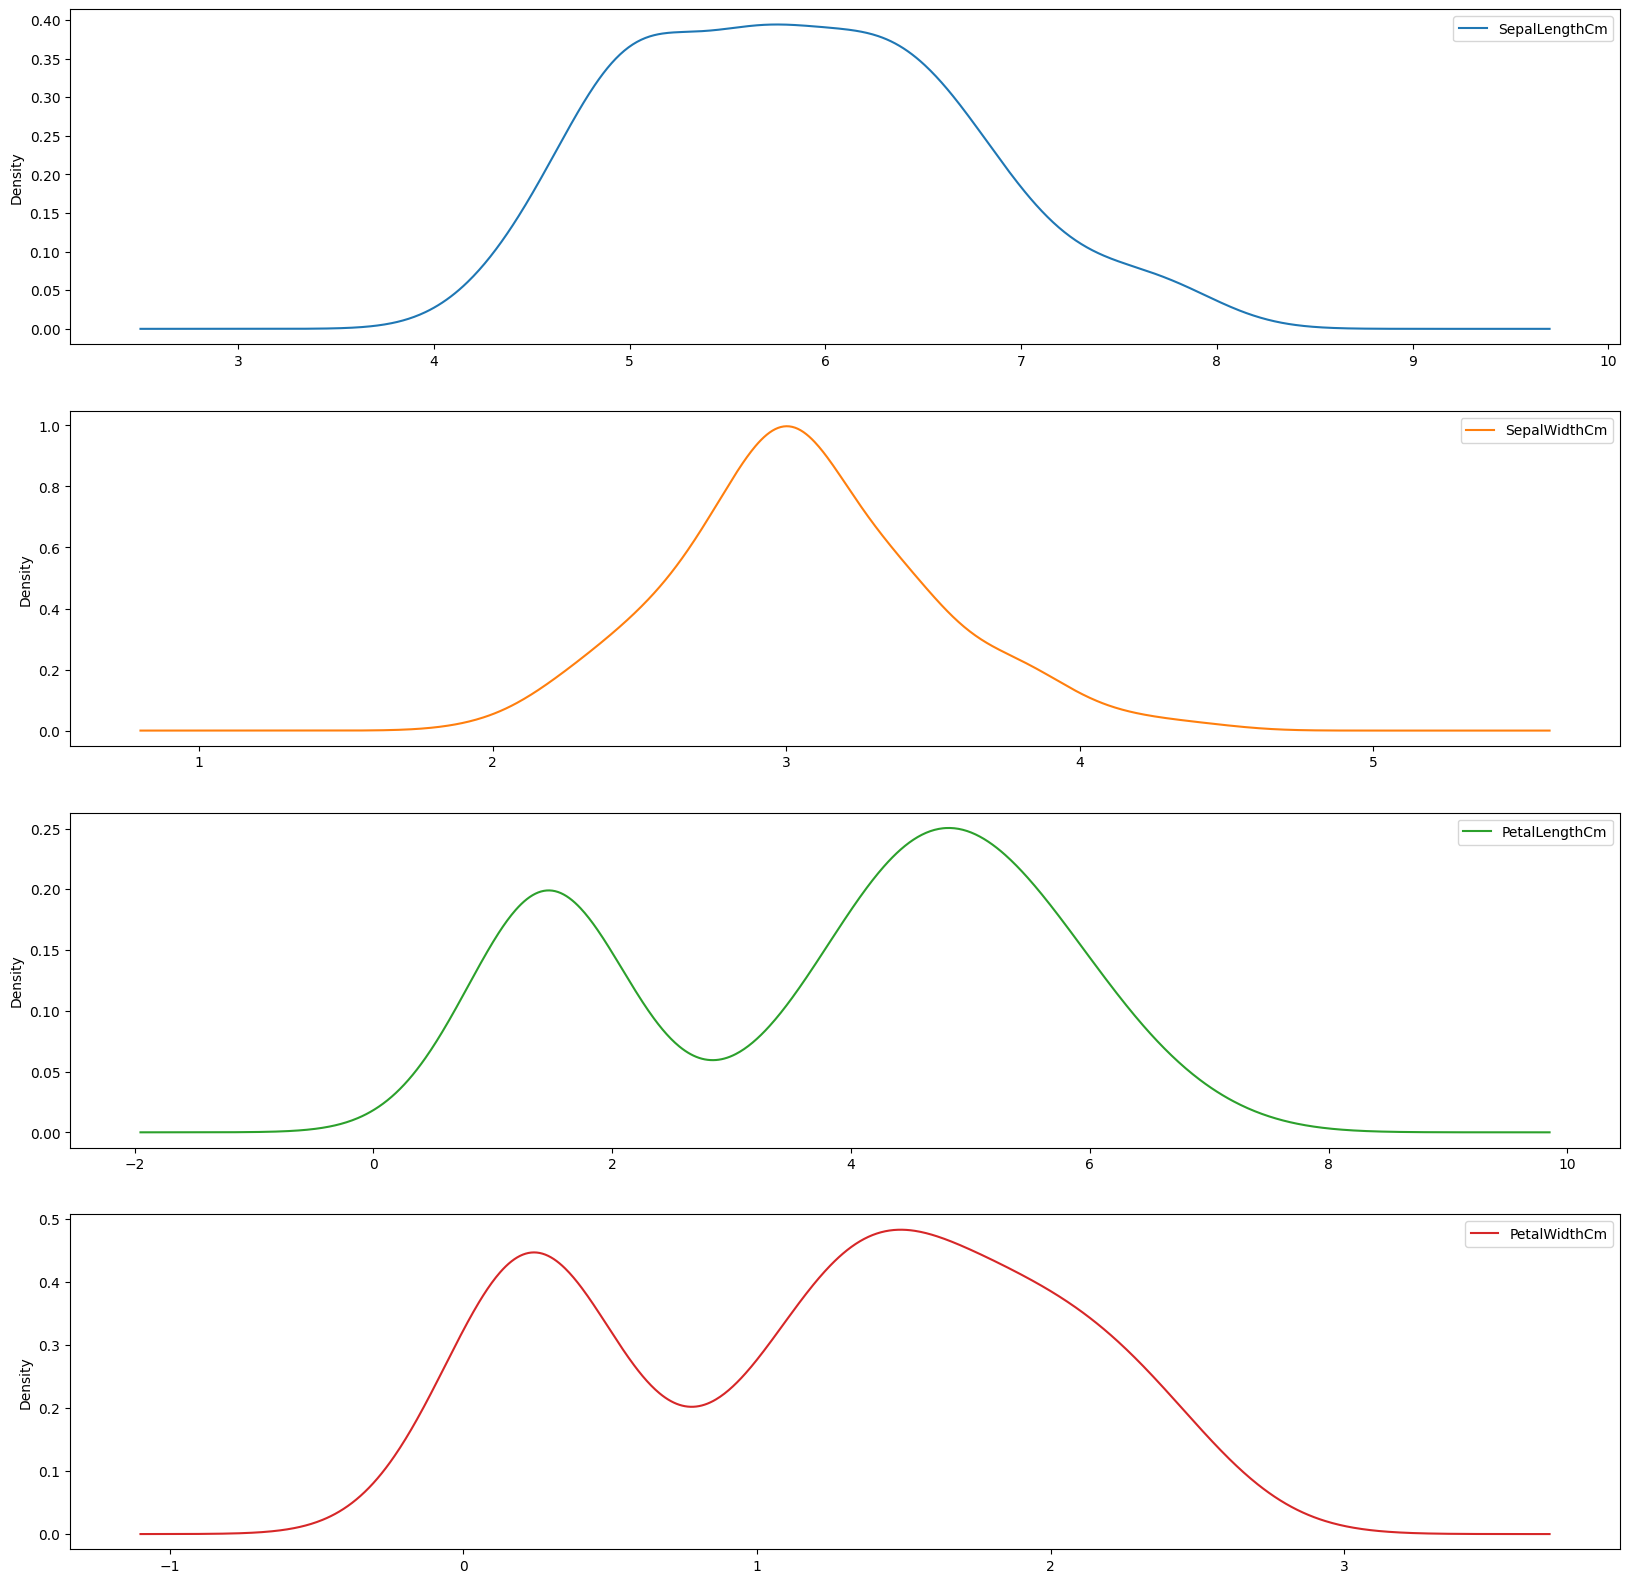

/tmp/ipykernel_2546/1590062410.py:6: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



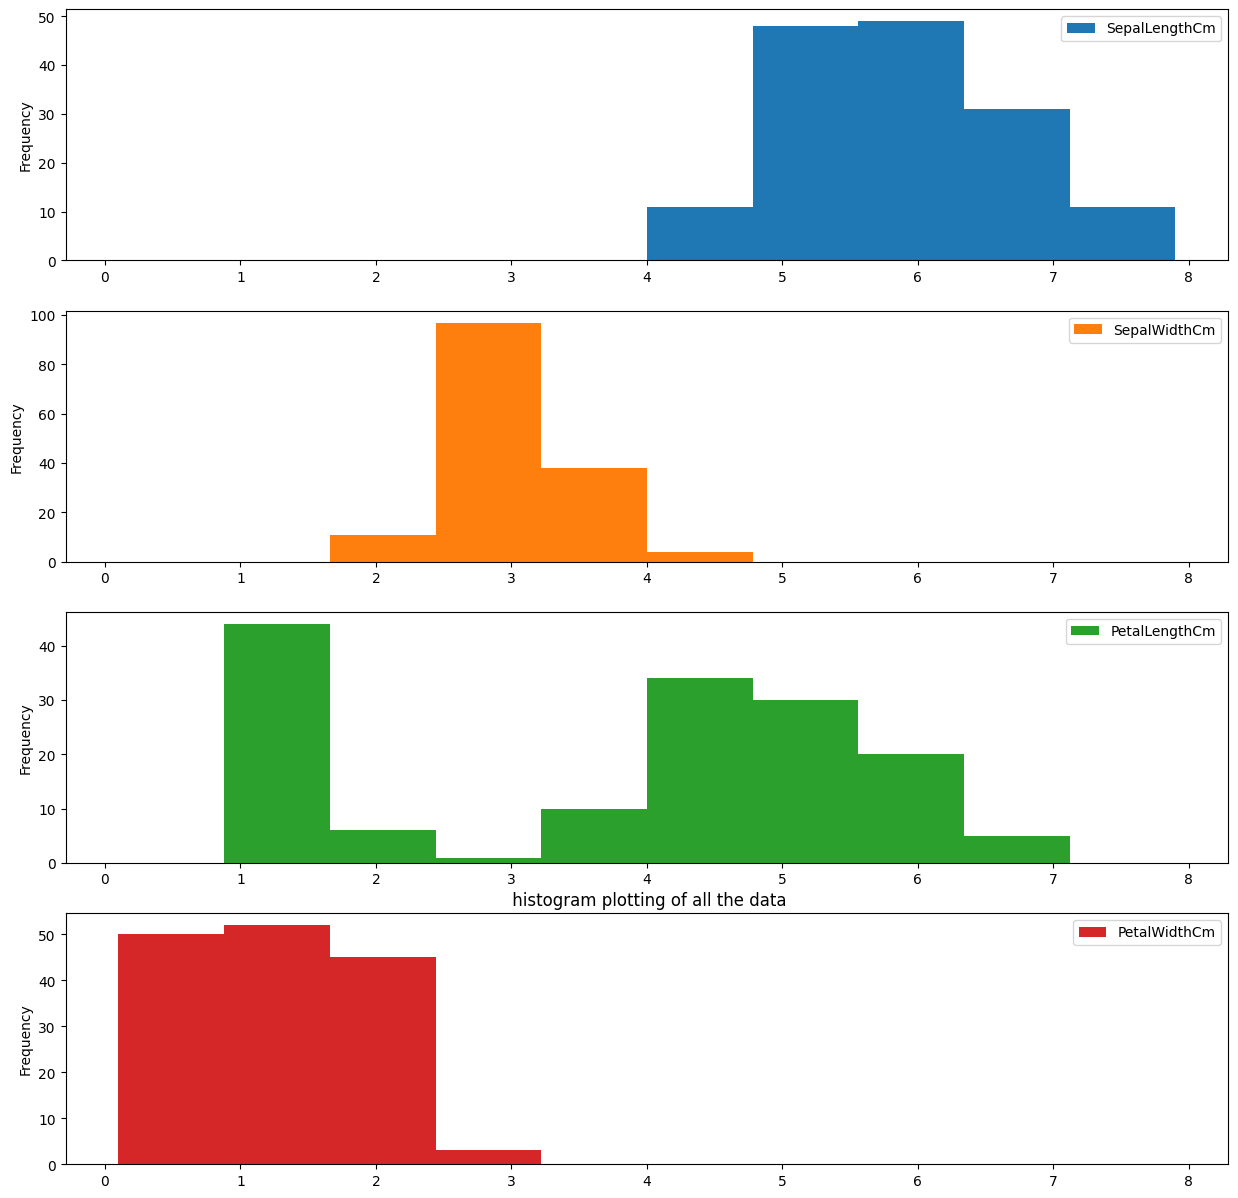

/tmp/ipykernel_2546/1590062410.py:12: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



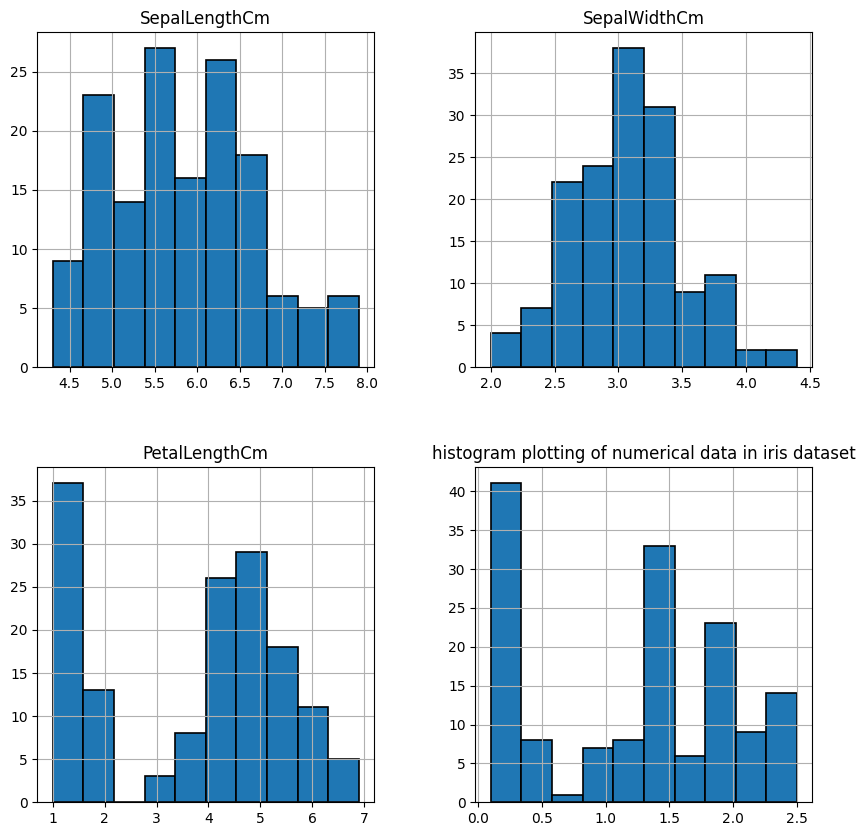

In [65]:
fig=plt.figure(figsize=(20,20))
df.drop(['Id'],axis="columns").plot(kind="kde",subplots=True,ax=plt.gca())
plt.show()

fig=plt.figure(figsize=(15,15))
df.drop(['Id'],axis="columns").plot(kind="hist",subplots=True,ax=plt.gca())
plt.title(' histogram plotting of all the data')
plt.show()

fig=plt.figure(figsize=(10,10))
ax=plt.gca()
df.drop(['Id'],axis="columns").hist(edgecolor='black', linewidth=1.2,ax=ax)
plt.title('histogram plotting of numerical data in iris dataset')
plt.show()

In [66]:
X = df.drop(['Id', 'Species'], axis=1).values
y = df['Species'].values

In [67]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['SpeciesCategory']=le.fit_transform(df['Species'])
label={0:'Iris-setosa',1:'Iris-versicolor',2:'Iris-virginica'}

In [68]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesCategory
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


In [69]:
X=df.drop(['Species','SpeciesCategory'],axis='columns')
y=df['SpeciesCategory']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=0.3)

In [70]:
knn_clf=KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train,y_train)
print("the predicted values of X_test are {}".format(knn_clf.predict(X_test)))
print("the accuracy score of trained data for KNN classifier is {}".format(knn_clf.score(X_train,y_train)))
print("the accuracy score of test and predicted data for KNN classifier is {}".format(knn_clf.score(X_test,knn_clf.predict(X_test))))

the predicted values of X_test are [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
the accuracy score of trained data for KNN classifier is 1.0
the accuracy score of test and predicted data for KNN classifier is 1.0


In [71]:
fig=px.scatter(df,x='PetalLengthCm',y='PetalWidthCm',color='Species',title='PetalLengthCm vs PetalWidthCm in KNN Classifier',size='PetalWidthCm',hover_data=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm','Species'],template="plotly_dark")
fig.show()

In [72]:
svm_clf=SVC()
svm_clf.fit(X_train,y_train)
print("the predicted values of X_test are {}".format(svm_clf.predict(X_test)))
print("the accuracy score of trained data for SVM is {}".format(svm_clf.score(X_train,y_train)))
print("the accuracy score of test and predicted data for SVM is {}".format(svm_clf.score(X_test,svm_clf.predict(X_test))))

the predicted values of X_test are [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
the accuracy score of trained data for SVM is 0.9904761904761905
the accuracy score of test and predicted data for SVM is 1.0


In [73]:
accuracy=[]
c=range(1,10)
for i in c:
    svm_clf=KNeighborsClassifier(n_neighbors=i)
    svm_clf.fit(X_train,y_train)
    accuracy.append(svm_clf.score(X_train,y_train))
px.line(c,accuracy,title='Regularization factor(C) vs accuracy',template='plotly_dark')

In [74]:
mnb=MultinomialNB()
bnb=BernoulliNB()
gnb=GaussianNB()
mnb.fit(X_train,y_train)
bnb.fit(X_train,y_train)
gnb.fit(X_train,y_train)
print("the accuracy score of trained data for MultinomialNB is {}".format(mnb.score(X_train,y_train)))
print("the accuracy score of test and predicted data for MultinomialNB is {}".format(mnb.score(X_test,mnb.predict(X_test))))
print("the accuracy score of trained data for BernoulliNB is {}".format(bnb.score(X_train,y_train)))
print("the accuracy score of test and predicted data for BernoulliNB is {}".format(bnb.score(X_test,bnb.predict(X_test))))
print("the accuracy score of trained data for GaussianNB is {}".format(gnb.score(X_train,y_train)))
print("the accuracy score of test and predicted data for GaussianNB is {}".format(gnb.score(X_test,gnb.predict(X_test))))

the accuracy score of trained data for MultinomialNB is 0.7904761904761904
the accuracy score of test and predicted data for MultinomialNB is 1.0
the accuracy score of trained data for BernoulliNB is 0.37142857142857144
the accuracy score of test and predicted data for BernoulliNB is 1.0
the accuracy score of trained data for GaussianNB is 0.9904761904761905
the accuracy score of test and predicted data for GaussianNB is 1.0


In [75]:
dec_tree=DecisionTreeClassifier(max_depth=10)
dec_tree.fit(X_train,y_train)
print("predicted data is:",svm_clf.predict(X_test))
print("the accuracy score of trained data for DecisionTreeClassifier is {}".format(svm_clf.score(X_train,y_train)))
print("the accuracy score of test and predicted data for DecisionTreeClassifier is {}".format(svm_clf.score(X_test,svm_clf.predict(X_test))))

predicted data is: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
the accuracy score of trained data for DecisionTreeClassifier is 1.0
the accuracy score of test and predicted data for DecisionTreeClassifier is 1.0


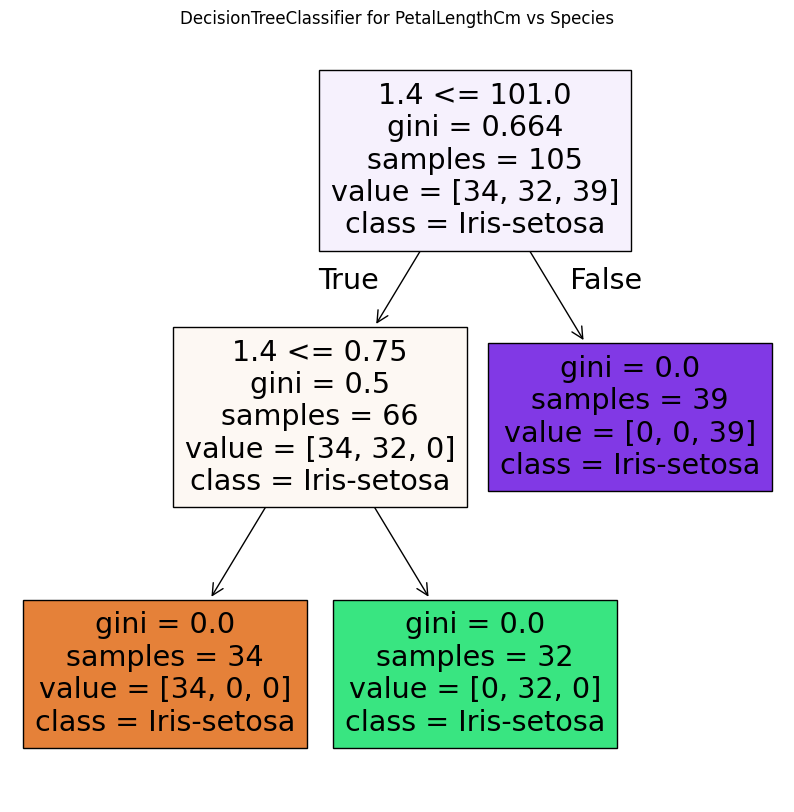

In [76]:
from sklearn import tree
fig=plt.figure(figsize=(10,10))
_=tree.plot_tree(dec_tree,feature_names=df.PetalLengthCm,class_names=df.Species,filled=True)
plt.title('DecisionTreeClassifier for PetalLengthCm vs Species')
fig.show()

In [77]:
accuracy=[]
max_depth=range(1,10)
for i in max_depth:
    dec_tree=KNeighborsClassifier(n_neighbors=i)
    dec_tree.fit(X_train,y_train)
    accuracy.append(dec_tree.score(X_test,svm_clf.predict(X_test)))
px.line(max_depth,accuracy,title='max_depth of the tree vs accuracy',template='plotly_dark')

In [78]:
forest_clf=RandomForestClassifier(n_estimators=5)
forest_clf.fit(X_train,y_train)
print("the predicted values are:",forest_clf.predict(X_test))
print("the accuracy score of trained data for DecisionTreeClassifier is",forest_clf.score(X_train,y_train))
print("the accuracy score of tested and predicted data for DecisionTreeClassifier is",forest_clf.score(X_test,forest_clf.predict(X_test)))

the predicted values are: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
the accuracy score of trained data for DecisionTreeClassifier is 1.0
the accuracy score of tested and predicted data for DecisionTreeClassifier is 1.0


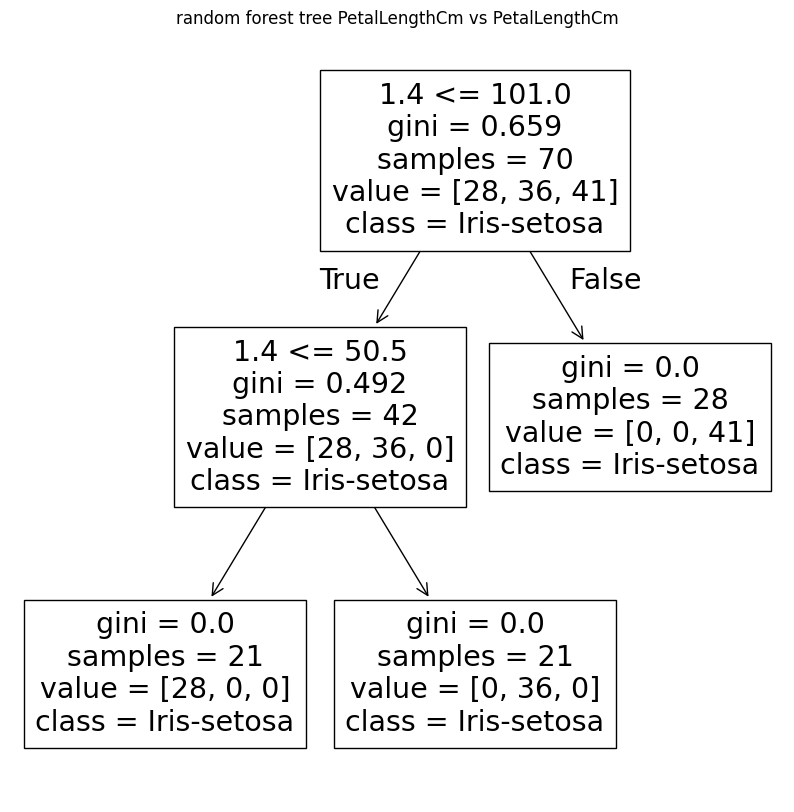

In [79]:
fig=plt.figure(figsize=(10,10))
_=tree.plot_tree(forest_clf.estimators_[3],feature_names=df.PetalLengthCm,class_names=df.Species)
plt.title("random forest tree PetalLengthCm vs PetalLengthCm")
plt.show()

In [80]:
accuracy=[]
n_estimators=range(1,10)
for i in n_estimators:
    forest_clf=RandomForestClassifier(n_estimators=5)
    forest_clf.fit(X_train,y_train)
    accuracy.append(forest_clf.score(X_test,forest_clf.predict(X_test)))
px.line(n_estimators,accuracy,title='n_estimators of the random forest classifier vs accuracy',template='plotly_dark')

In [81]:
log_reg=LogisticRegression(C=100)
log_reg.fit(X_train,y_train)
print("the predicted values are:",log_reg.predict(X_test))
print("the accuracy score of trained data for DecisionTreeClassifier is",log_reg.score(X_train,y_train))
print("the accuracy score of tested and predicted data for DecisionTreeClassifier is",log_reg.score(X_test,log_reg.predict(X_test)))

the predicted values are: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]
the accuracy score of trained data for DecisionTreeClassifier is 1.0
the accuracy score of tested and predicted data for DecisionTreeClassifier is 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [82]:
C_range=range(1,200)
accuracy=[]
for n in C_range:
    log_reg=LogisticRegression(C=n)
    log_reg.fit(X_train,y_train)
    accuracy.append(log_reg.score(X_test,log_reg.predict(X_test)))
px.line(C_range,accuracy,title='Regularization factor(C) of the tree vs accuracy',template='plotly_dark')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/